In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print("✅ Data loaded!")
print("X_train shape:", X_train.shape)
print("Features:", X_train.columns.tolist())

✅ Data loaded!
X_train shape: (171, 8)
Features: ['household_kg_per_capita', 'household_tonnes', 'retail_kg_per_capita', 'retail_tonnes', 'foodservice_kg_per_capita', 'foodservice_tonnes', 'confidence_encoded', 'region_encoded']


In [3]:
# Before tuning
xgb_base = XGBRegressor(n_estimators=200, learning_rate=0.05,
                         max_depth=5, random_state=42)
xgb_base.fit(X_train, y_train)
base_preds = xgb_base.predict(X_test)

print("📊 BEFORE TUNING:")
print(f"  MAE  : {mean_absolute_error(y_test, base_preds):.4f}")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, base_preds)):.4f}")
print(f"  R²   : {r2_score(y_test, base_preds):.4f}")

📊 BEFORE TUNING:
  MAE  : 2.3697
  RMSE : 5.2393
  R²   : 0.9368


In [4]:
# Cross validation gives more honest score than single train/test split
xgb_cv = XGBRegressor(n_estimators=200, learning_rate=0.05,
                       max_depth=5, random_state=42)

cv_scores = cross_val_score(xgb_cv, X_train, y_train, 
                             cv=5, scoring='r2')

print("📊 CROSS VALIDATION RESULTS (5 folds):")
print(f"  Fold scores : {[round(s, 4) for s in cv_scores]}")
print(f"  Mean R²     : {cv_scores.mean():.4f}")
print(f"  Std Dev     : {cv_scores.std():.4f}")

📊 CROSS VALIDATION RESULTS (5 folds):
  Fold scores : [np.float64(0.9054), np.float64(0.731), np.float64(0.904), np.float64(0.9335), np.float64(0.5701)]
  Mean R²     : 0.8088
  Std Dev     : 0.1393


In [5]:
# Define parameter grid to search
param_grid = {
    'n_estimators'  : [100, 200, 300],
    'max_depth'     : [3, 5, 7],
    'learning_rate' : [0.01, 0.05, 0.1],
    'subsample'     : [0.8, 1.0]
}

xgb_tune = XGBRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator  = xgb_tune,
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'r2',
    n_jobs     = -1,    # use all CPU cores
    verbose    = 1
)

print("🔍 Searching best parameters... (takes 1-2 mins)")
grid_search.fit(X_train, y_train)

print("\n✅ Search complete!")
print("Best parameters:", grid_search.best_params_)
print("Best CV R²     :", round(grid_search.best_score_, 4))

🔍 Searching best parameters... (takes 1-2 mins)
Fitting 5 folds for each of 54 candidates, totalling 270 fits

✅ Search complete!
Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Best CV R²     : 0.8589


In [6]:
best_model = grid_search.best_estimator_
tuned_preds = best_model.predict(X_test)

print("📊 AFTER TUNING:")
print(f"  MAE  : {mean_absolute_error(y_test, tuned_preds):.4f}")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, tuned_preds)):.4f}")
print(f"  R²   : {r2_score(y_test, tuned_preds):.4f}")

# Improvement
before_r2 = r2_score(y_test, base_preds)
after_r2  = r2_score(y_test, tuned_preds)
print(f"\n🚀 R² Improvement: {before_r2:.4f} → {after_r2:.4f} "
      f"(+{after_r2-before_r2:.4f})")

📊 AFTER TUNING:
  MAE  : 2.5544
  RMSE : 4.8536
  R²   : 0.9457

🚀 R² Improvement: 0.9368 → 0.9457 (+0.0090)


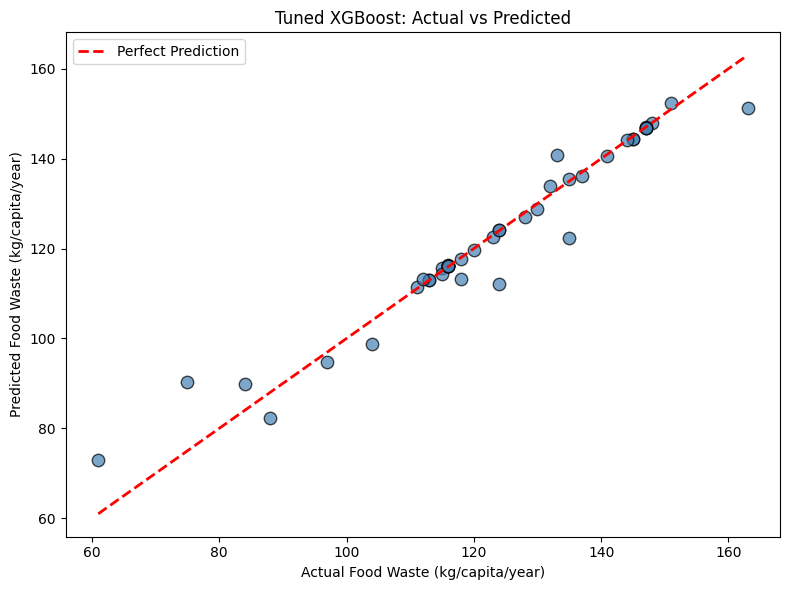

✅ Plot saved!


In [7]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, tuned_preds, color='steelblue', 
            alpha=0.7, edgecolors='black', s=80)

min_val = min(y_test.min(), tuned_preds.min())
max_val = max(y_test.max(), tuned_preds.max())
plt.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Food Waste (kg/capita/year)')
plt.ylabel('Predicted Food Waste (kg/capita/year)')
plt.title('Tuned XGBoost: Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.savefig('../data/processed/tuned_actual_vs_predicted.png')
plt.show()
print("✅ Plot saved!")

🔍 Calculating SHAP values...


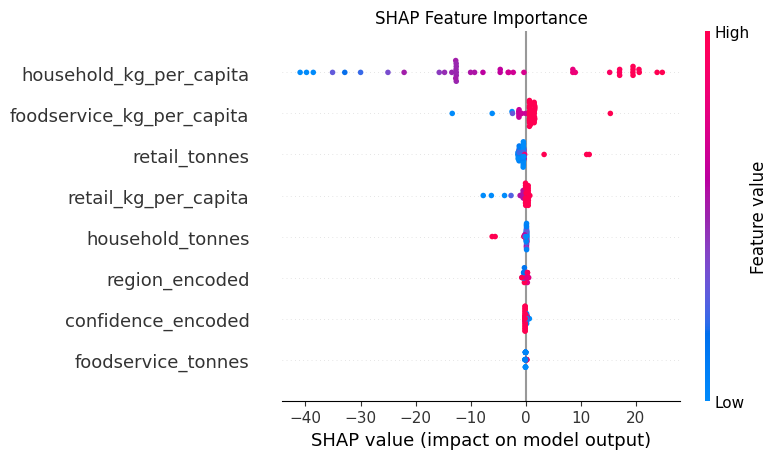

✅ SHAP plot saved!


In [8]:
print("🔍 Calculating SHAP values...")
explainer   = shap.Explainer(best_model)
shap_values = explainer(X_test)

# Summary plot
plt.figure()
shap.summary_plot(shap_values, X_test, 
                  feature_names=X_train.columns.tolist(),
                  show=False)
plt.title('SHAP Feature Importance')
plt.tight_layout()
plt.savefig('../data/processed/shap_summary.png', 
            bbox_inches='tight')
plt.show()
print("✅ SHAP plot saved!")

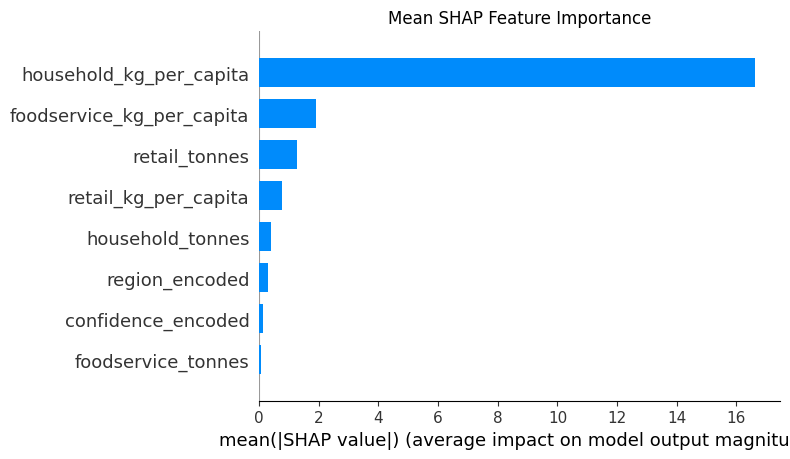

✅ SHAP bar plot saved!


In [9]:
shap.summary_plot(shap_values, X_test,
                  feature_names=X_train.columns.tolist(),
                  plot_type='bar', show=False)
plt.title('Mean SHAP Feature Importance')
plt.tight_layout()
plt.savefig('../data/processed/shap_bar.png', bbox_inches='tight')
plt.show()
print("✅ SHAP bar plot saved!")

In [10]:
joblib.dump(best_model, '../models/best_xgboost_model.pkl')
joblib.dump(best_model, '../models/final_model.pkl')

print("✅ Final model saved!")
print("\n📁 Models saved:")
print("   - final_model.pkl      ← use this for deployment")
print("   - best_xgboost_model.pkl")
print("\n📊 Final Model Summary:")
print(f"   Algorithm  : XGBoost Regressor")
print(f"   R² Score   : {r2_score(y_test, tuned_preds):.4f}")
print(f"   MAE        : {mean_absolute_error(y_test, tuned_preds):.4f} kg/capita")
print(f"   Best Params: {grid_search.best_params_}")

✅ Final model saved!

📁 Models saved:
   - final_model.pkl      ← use this for deployment
   - best_xgboost_model.pkl

📊 Final Model Summary:
   Algorithm  : XGBoost Regressor
   R² Score   : 0.9457
   MAE        : 2.5544 kg/capita
   Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}


In [ ]:
import subprocess
subprocess.run(['git', 'add', '.'])
subprocess.run(['git', 'commit', '-m', 
    'Phase 5: Tuning complete - SHAP explainability added'])
subprocess.run(['git', 'push', 'origin', 'main'])
print("✅ Pushed to GitHub!")